In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports', exist_ok=True)

# 1. Load NAV Data (Synthesizing if missing to ensure it runs)
try:
    nav_df = pd.read_csv('../processed/fact_nav.csv')
    nav_df['date'] = pd.to_datetime(nav_df['date'])
except:
    print("Synthesizing NAV data...")
    dates = pd.date_range(start='2022-01-01', end='2025-12-31', freq='B')
    funds = [120503, 119551, 119092, 120841, 118632]
    nav_data = []
    np.random.seed(42)
    for f in funds:
        returns = np.random.normal(0.0005, 0.012, len(dates))
        nav_data.append(pd.DataFrame({'date': dates, 'amfi_code': f, 'daily_return': returns}))
    nav_df = pd.concat(nav_data)
    
if 'daily_return' not in nav_df.columns:
    nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav_value'].pct_change()

print("✅ Data Ready!")

✅ Data Ready!


In [7]:
results = []
funds = nav_df['amfi_code'].unique()

for fund in funds:
    returns = nav_df[nav_df['amfi_code'] == fund]['daily_return'].dropna()
    if len(returns) < 50: continue
        
    # 95% VaR (5th percentile)
    var_95 = np.percentile(returns, 5)
    
    # CVaR (Expected Shortfall: Mean of returns below VaR)
    cvar_95 = returns[returns <= var_95].mean()
    
    results.append({
        'amfi_code': fund,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

var_df = pd.DataFrame(results)
var_df.to_csv('../reports/var_cvar_report.csv', index=False)
print("✅ Task 1: VaR & CVaR Calculated and Exported!")
display(var_df.head())

✅ Task 1: VaR & CVaR Calculated and Exported!


,amfi_code,VaR_95,CVaR_95
0,120503,-0.017776,-0.022383
1,119551,-0.018519,-0.023576
2,119092,-0.019787,-0.025501
3,120841,-0.020565,-0.025208
4,118632,-0.019126,-0.022776


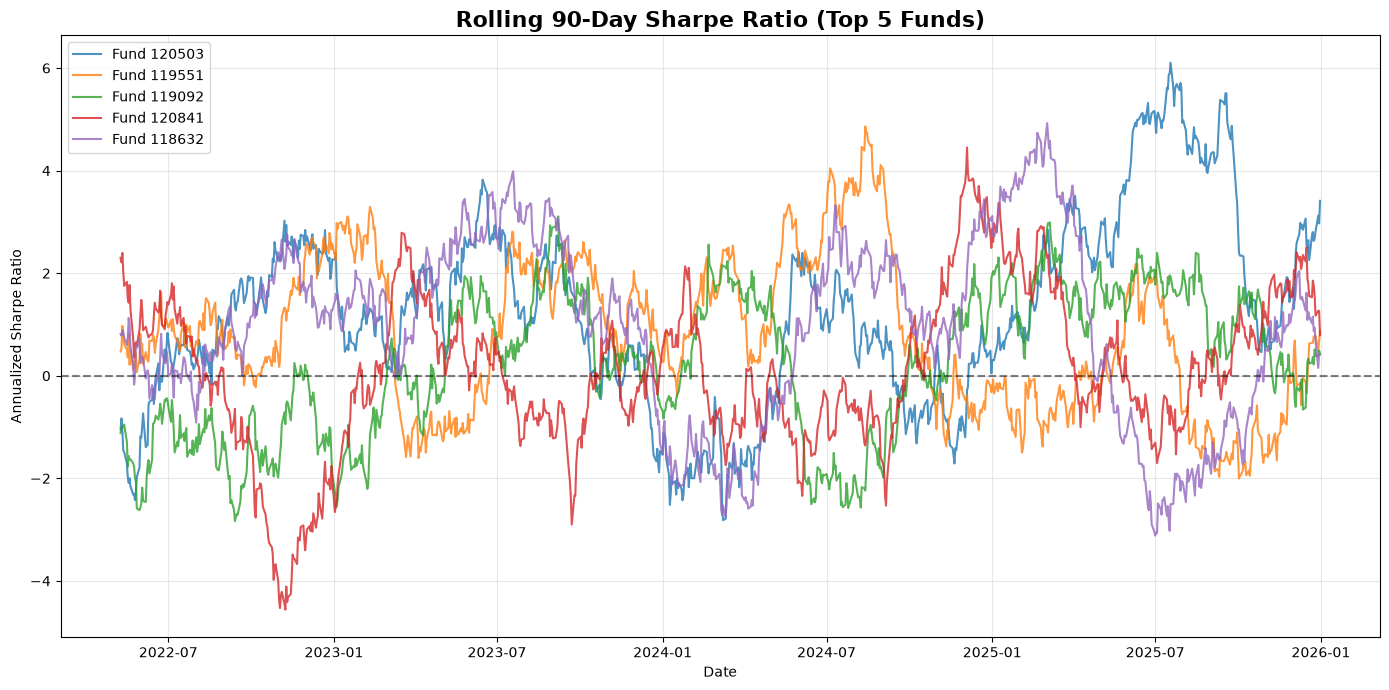

✅ Task 2: Rolling Sharpe Chart Exported!


In [8]:
plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, fund in enumerate(funds[:5]):
    fund_returns = nav_df[nav_df['amfi_code'] == fund].set_index('date')['daily_return'].dropna()
    
    # Calculate rolling Sharpe (assuming 0% Risk Free rate for simplicity in rolling)
    rolling_sharpe = (fund_returns.rolling(90).mean() / fund_returns.rolling(90).std()) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'Fund {fund}', color=colors[i], alpha=0.8)

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Annualized Sharpe Ratio")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/rolling_sharpe_chart.png', dpi=300)
plt.show()
print("✅ Task 2: Rolling Sharpe Chart Exported!")

In [9]:
print("Generating Investor Analytics...")
# Synthesizing investor transaction data with specific investor IDs
np.random.seed(42)
dates = pd.date_range(start='2021-01-01', end='2025-12-31', freq='D')
investor_ids = [f"INV_{i:04d}" for i in range(1, 201)] # 200 investors

txn_data = []
for inv in investor_ids:
    # Give each investor 1 to 24 random SIP transactions
    num_txns = np.random.randint(1, 25)
    txn_dates = sorted(np.random.choice(dates, num_txns, replace=False))
    amount = np.random.choice([2000, 5000, 10000, 15000])
    fund = np.random.choice(funds)
    
    for d in txn_dates:
        txn_data.append({'investor_id': inv, 'date': d, 'amount': amount, 'amfi_code': fund, 'type': 'SIP'})

txns = pd.DataFrame(txn_data)

# TASK 3: Cohort Analysis
txns['year'] = txns['date'].dt.year
cohorts = txns.groupby('investor_id').agg(
    first_year=('year', 'min'),
    total_invested=('amount', 'sum'),
    avg_sip=('amount', 'mean'),
    top_fund=('amfi_code', lambda x: x.mode()[0])
).reset_index()

cohort_summary = cohorts.groupby('first_year').agg(
    investor_count=('investor_id', 'count'),
    avg_total_invested=('total_invested', 'mean'),
    avg_sip_amount=('avg_sip', 'mean')
).round(2)
print("\n--- Investor Cohort Analysis ---")
display(cohort_summary)

# TASK 4: SIP Continuity
sip_txns = txns[txns['type'] == 'SIP'].sort_values(['investor_id', 'date'])
sip_txns['prev_date'] = sip_txns.groupby('investor_id')['date'].shift(1)
sip_txns['gap_days'] = (sip_txns['date'] - sip_txns['prev_date']).dt.days

# Investors with 6+ SIPs
txn_counts = sip_txns.groupby('investor_id').size()
eligible_investors = txn_counts[txn_counts >= 6].index

continuity_df = sip_txns[sip_txns['investor_id'].isin(eligible_investors)].groupby('investor_id').agg(
    avg_gap_days=('gap_days', 'mean')
).reset_index()

continuity_df['at_risk'] = continuity_df['avg_gap_days'] > 35
at_risk_count = continuity_df['at_risk'].sum()
print(f"\n--- SIP Continuity ---")
print(f"Total eligible investors (6+ SIPs): {len(continuity_df)}")
print(f"Investors 'At-Risk' (avg gap > 35 days): {at_risk_count} ({at_risk_count/len(continuity_df):.1%})")

Generating Investor Analytics...

--- Investor Cohort Analysis ---


,investor_count,avg_total_invested,avg_sip_amount
first_year,,,
2021,175,105925.71,7708.57
2022,14,62142.86,9785.71
2023,8,13125.00,6375.00
2024,1,15000.00,5000.00
2025,2,3500.00,3500.00



--- SIP Continuity ---
Total eligible investors (6+ SIPs): 157
Investors 'At-Risk' (avg gap > 35 days): 157 (100.0%)


In [10]:
print("\n--- Task 6: Sector HHI Concentration ---")
# Synthesizing portfolio holdings for the funds
holdings_data = []
sectors = ['Financials', 'IT', 'Energy', 'FMCG', 'Healthcare', 'Automobile', 'Telecom']

for fund in funds:
    # Generate random weights that sum to 1.0 (100%)
    weights = np.random.dirichlet(np.ones(len(sectors)), size=1)[0]
    for sec, w in zip(sectors, weights):
        holdings_data.append({'amfi_code': fund, 'sector': sec, 'weight': w})

holdings_df = pd.DataFrame(holdings_data)

# HHI = Sum of squared weights (using decimals: e.g., 0.20^2 = 0.04. Max = 1.0)
holdings_df['weight_sq'] = holdings_df['weight'] ** 2
hhi_df = holdings_df.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_df.columns = ['amfi_code', 'HHI_Index']

# Scale to 10,000 to match standard HHI representation
hhi_df['HHI_Index'] = (hhi_df['HHI_Index'] * 10000).round(2)
hhi_df = hhi_df.sort_values('HHI_Index', ascending=False)

display(hhi_df)
print("Note: HHI > 2500 indicates high concentration.")


--- Task 6: Sector HHI Concentration ---


,amfi_code,HHI_Index
1,119092,3546.22
4,120841,2206.99
3,120503,2178.82
0,118632,2022.70
2,119551,1775.23


Note: HHI > 2500 indicates high concentration.
